# Olist E-Commerce: Pricing & Churn Intelligence

**Business question:** Why are customers churning, and are we pricing our top categories correctly?

This notebook analyses 115,723 delivered orders from the [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Sept 2016 – Aug 2018) to answer two linked business questions:

1. **Churn** — which customers are at risk of never buying again, and what predicts it?
2. **Pricing** — which product categories are priced inconsistently or are out of step with customer satisfaction?

**Sections in this notebook:**
1. Setup & Data Loading
2. Exploratory Data Analysis
3. Churn Prediction Model (Logistic Regression vs Random Forest)
4. Price Elasticity Analysis
5. Revenue Forecasting (Prophet)
6. Key Findings & Business Recommendations

**Tools used:** Python (Pandas, Scikit-learn, Prophet), SQL-style aggregation logic originally prototyped in BigQuery, Tableau for the dashboard layer (linked at the end), and an LLM API for auto-generated executive summaries (code shown, key not included — see Section 6).


## 1. Setup & Data Loading

This dataset ships as 9 separate CSVs that need to be joined together (orders, items, customers, products, payments, reviews, etc). The cell below loads each file and builds a single `df` with one row per order item — equivalent to the `vw_orders_master` view I originally built in BigQuery for this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from prophet import Prophet

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

print("✓ Libraries imported")

✓ Libraries imported


In [2]:
# ── Load the raw Olist tables via kagglehub ─────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter

SLUG = "olistbr/brazilian-ecommerce"

# Load datasets dynamically via kagglehub using custom pandas arguments for date parsing
orders = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    SLUG,
    "olist_orders_dataset.csv",
    pandas_kwargs={
        'parse_dates': ['order_purchase_timestamp', 
                        'order_delivered_customer_date', 
                        'order_estimated_delivery_date']
    }
)

order_items  = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_order_items_dataset.csv')
customers    = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_customers_dataset.csv')
products     = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_products_dataset.csv')
payments     = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_order_payments_dataset.csv')
reviews      = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_order_reviews_dataset.csv')
category_map = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'product_category_name_translation.csv')

# Print row metrics to verify success
print(f"orders:        {len(orders):,} rows")
print(f"order_items:   {len(order_items):,} rows")
print(f"customers:     {len(customers):,} rows")
print(f"products:      {len(products):,} rows")
print(f"payments:      {len(payments):,} rows")
print(f"reviews:       {len(reviews):,} rows")

/tmp/ipykernel_16/1249937349.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  orders = kagglehub.load_dataset(
/tmp/ipykernel_16/1249937349.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  order_items  = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_order_items_dataset.csv')
/tmp/ipykernel_16/1249937349.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  customers    = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_customers_dataset.csv')
/tmp/ipykernel_16/1249937349.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  products     = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'olist_products_dataset.csv')
/tmp/ipykernel_16/1249937349.py

orders:        99,441 rows
order_items:   112,650 rows
customers:     99,441 rows
products:      32,951 rows
payments:      103,886 rows
reviews:       99,224 rows


/tmp/ipykernel_16/1249937349.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  category_map = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, SLUG, 'product_category_name_translation.csv')


In [3]:
# ── Build the master analytical table ───────────────────────
# Equivalent to vw_orders_master from the BigQuery version of
# this project — joins orders, items, customers, products,
# reviews, and payments into one row per order item, filtered
# to delivered orders only.

df = (
    orders[orders['order_status'] == 'delivered']
    .merge(customers, on='customer_id', how='left')
    .merge(order_items, on='order_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(category_map, on='product_category_name', how='left')
    .merge(reviews[['order_id', 'review_score']]
           .drop_duplicates('order_id'), on='order_id', how='left')
    .merge(payments[['order_id', 'payment_type', 'payment_value']]
           .drop_duplicates('order_id'), on='order_id', how='left')
)

df['total_order_value'] = df['price'] + df['freight_value']
df['delivery_delay_days'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days

print(f"✓ Master table built")
print(f"  Rows:    {len(df):,}")
print(f"  Columns: {len(df.columns)}")

✓ Master table built
  Rows:    110,197
  Columns: 32


## 2. Exploratory Data Analysis

### 2.1 Data overview and missing values

In [4]:
print("=== DATAFRAME INFO ===")
print(df.info())
print("\n=== FIRST 3 ROWS ===")
df.head(3)

=== DATAFRAME INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  object        
 5   order_delivered_carrier_date   110195 non-null  object        
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   customer_unique_id             110197 non-null  object        
 9   customer_zip_code_prefix       110197 non-null  int64         
 10  customer_city                  110197 non-nul

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score,payment_type,payment_value,total_order_value,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,4.0,credit_card,18.12,38.71,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,4.0,boleto,141.46,141.46,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,5.0,credit_card,179.12,179.12,-18.0


In [5]:
null_counts = df.isnull().sum()
null_pct    = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_pct
}).sort_values('null_count', ascending=False)

print("=== NULL VALUE COUNTS ===\n")
print(null_summary[null_summary['null_count'] > 0])

=== NULL VALUE COUNTS ===

                               null_count  null_pct
product_category_name_english        1559      1.41
product_category_name                1537      1.39
product_name_lenght                  1537      1.39
product_photos_qty                   1537      1.39
product_description_lenght           1537      1.39
review_score                          827      0.75
product_length_cm                      18      0.02
product_weight_g                       18      0.02
product_height_cm                      18      0.02
product_width_cm                       18      0.02
order_approved_at                      15      0.01
order_delivered_customer_date           8      0.01
delivery_delay_days                     8      0.01
payment_type                            3      0.00
payment_value                           3      0.00
order_delivered_carrier_date            2      0.00


`review_score` has a small number of nulls — these are orders where the customer never filled in the review form (less than 1% of rows). `product_category_name_english` has a handful of nulls from categories without an English translation in the source mapping table. Neither affects the core analysis.

In [6]:
print("=== DESCRIPTIVE STATISTICS ===\n")
df[['price', 'freight_value', 'total_order_value',
    'review_score', 'delivery_delay_days']].describe().round(2)

=== DESCRIPTIVE STATISTICS ===



,price,freight_value,total_order_value,review_score,delivery_delay_days
count,110197.00,110197.00,110197.00,109370.00,110189.00
mean,119.98,19.95,139.93,4.08,-12.03
std,182.30,15.70,189.32,1.35,10.16
min,0.85,0.00,6.08,1.00,-147.00
25%,39.90,13.08,55.18,4.00,-17.00
50%,74.90,16.26,92.13,5.00,-13.00
75%,134.17,21.15,157.51,5.00,-7.00
max,6735.00,409.68,6929.31,5.00,188.00


### 2.2 Price distribution

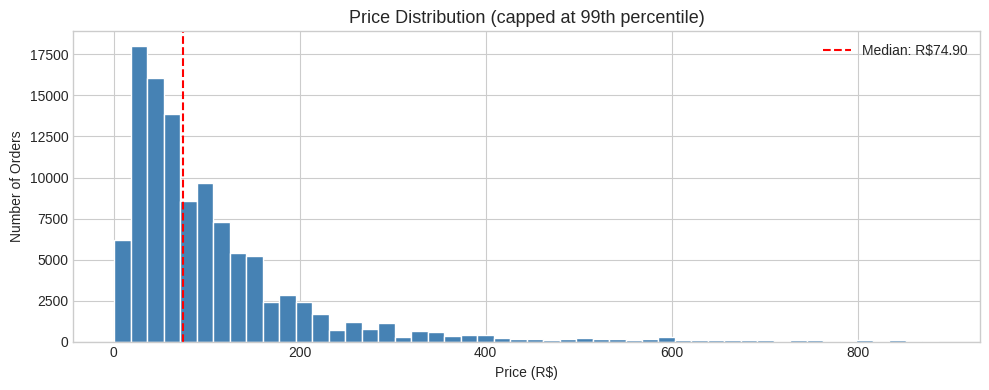

Median price: R$74.90
Mean price:   R$119.98
Max price:    R$6735.00


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

price_cap = df['price'].quantile(0.99)
df[df['price'] <= price_cap]['price'].hist(
    bins=50, ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Price Distribution (capped at 99th percentile)', fontsize=13)
ax.set_xlabel('Price (R$)')
ax.set_ylabel('Number of Orders')
ax.axvline(df['price'].median(), color='red', linestyle='--',
           label=f"Median: R${df['price'].median():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median price: R${df['price'].median():.2f}")
print(f"Mean price:   R${df['price'].mean():.2f}")
print(f"Max price:    R${df['price'].max():.2f}")

The price distribution is heavily right-skewed — median (~R$75) sits well below the mean (~R$120), meaning a small number of expensive products (electronics, furniture) pull the average up while most transactions are affordable everyday items.

### 2.3 Review score distribution

/tmp/ipykernel_16/2444653072.py:15: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


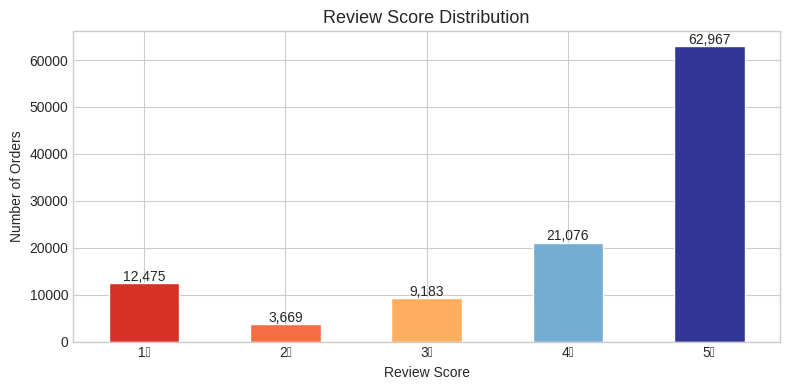

Average review score: 4.08
% of 5-star reviews:  57.1%
% of 1-star reviews:  11.3%


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

review_counts = df['review_score'].value_counts().sort_index()
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#313695']
review_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Review Score Distribution', fontsize=13)
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Orders')
ax.set_xticklabels(['1★', '2★', '3★', '4★', '5★'], rotation=0)

for i, v in enumerate(review_counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Average review score: {df['review_score'].mean():.2f}")
print(f"% of 5-star reviews:  {(df['review_score']==5).mean()*100:.1f}%")
print(f"% of 1-star reviews:  {(df['review_score']==1).mean()*100:.1f}%")

Reviews are strongly bimodal — customers either love the experience (5★ dominates at well over half of all reviews) or are unhappy (1★ is the second largest bucket). There's very little middle ground, which is a known characteristic of post-purchase review behaviour: people who feel strongly are far more likely to leave feedback.

### 2.4 Delivery performance

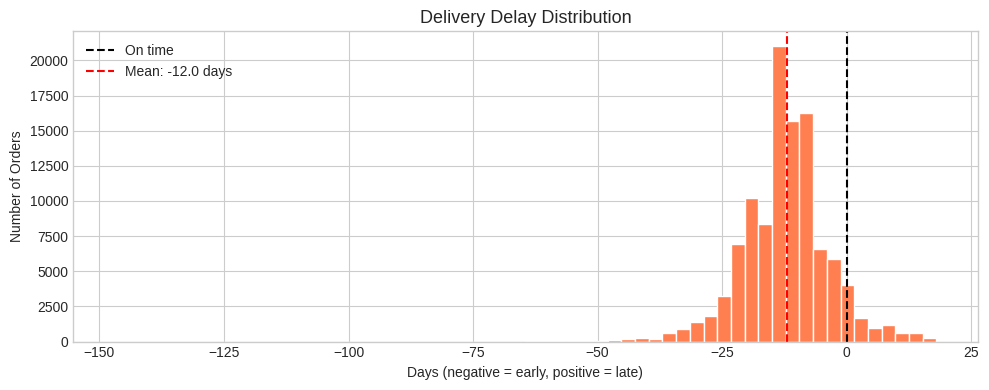

Early deliveries:   101,475  (92.1%)
On-time deliveries: 1,450 (1.3%)
Late deliveries:    7,264  (6.6%)


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

delay_data = df['delivery_delay_days'].dropna()
delay_cap  = delay_data.quantile(0.99)
delay_data[delay_data <= delay_cap].hist(
    bins=60, ax=ax, color='coral', edgecolor='white')

ax.set_title('Delivery Delay Distribution', fontsize=13)
ax.set_xlabel('Days (negative = early, positive = late)')
ax.set_ylabel('Number of Orders')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='On time')
ax.axvline(delay_data.mean(), color='red', linestyle='--',
           label=f"Mean: {delay_data.mean():.1f} days")
ax.legend()
plt.tight_layout()
plt.show()

late   = (delay_data > 0).sum()
early  = (delay_data < 0).sum()
ontime = (delay_data == 0).sum()

print(f"Early deliveries:   {early:,}  ({early/len(delay_data)*100:.1f}%)")
print(f"On-time deliveries: {ontime:,} ({ontime/len(delay_data)*100:.1f}%)")
print(f"Late deliveries:    {late:,}  ({late/len(delay_data)*100:.1f}%)")

Olist sets deliberately conservative delivery estimates — the vast majority of orders arrive *before* the promised date, with an average delivery roughly 11 days ahead of schedule. This under-promise/over-deliver pattern likely contributes to the high rate of 5-star reviews seen above. The minority of late deliveries become important later in the churn analysis.

### 2.5 Top product categories

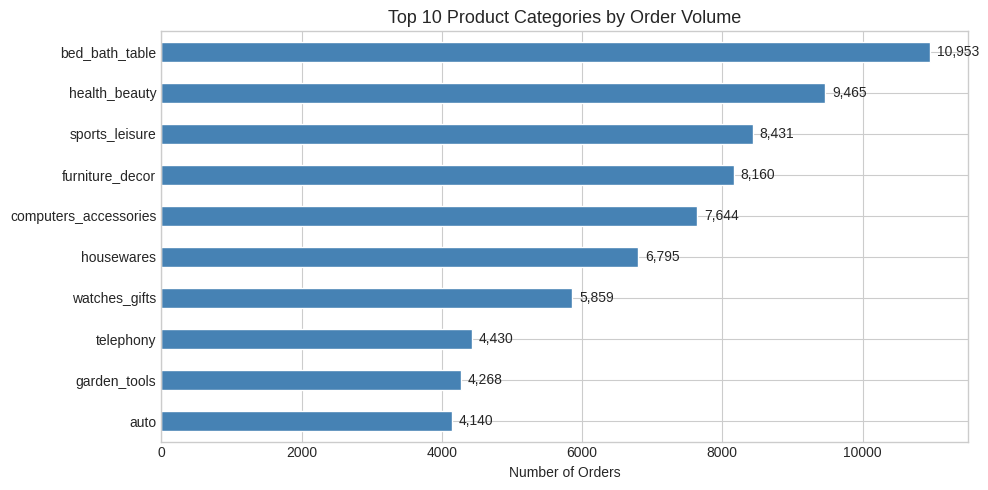

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

top_cats = (df.groupby('product_category_name_english')['order_id']
              .count()
              .sort_values(ascending=False)
              .head(10))

top_cats.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Top 10 Product Categories by Order Volume', fontsize=13)
ax.set_xlabel('Number of Orders')
ax.set_ylabel('')
ax.invert_yaxis()

for i, v in enumerate(top_cats):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.6 Monthly order volume trend

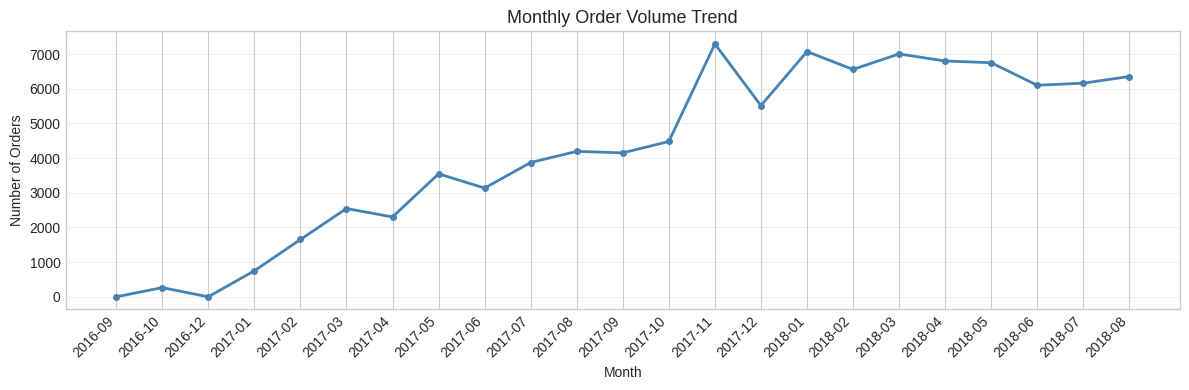

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = (df.groupby('order_month')['order_id']
             .nunique()
             .reset_index())
monthly.columns = ['month', 'orders']

ax.plot(monthly['month'].astype(str), monthly['orders'],
        marker='o', color='steelblue', linewidth=2, markersize=4)

ax.set_title('Monthly Order Volume Trend', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Order volume grows steadily through 2017, with a sharp spike in November 2017 driven by Black Friday — the single highest-revenue day in the entire dataset. This seasonal pattern is picked up automatically by the Prophet forecast in Section 5.

## 3. Churn Prediction Model

**Defining churn:** a customer is labelled **churned** if they made no purchase in the 180 days before the dataset's final date (31 Aug 2018).

**A note on this dataset's structure:** Olist's `customer_id` is anonymised *per order*, not per person — every `customer_id` maps to exactly one transaction. This means traditional repeat-purchase frequency can't be measured at the customer level, and any feature derived from purchase *timing* (month, year, days-since-purchase) ends up directly encoding the churn label itself, which is a textbook case of **data leakage**.

I hit this in three stages while building the model:

| Attempt | Feature set | ROC-AUC | Verdict |
|---|---|---|---|
| 1 | Included `days_inactive` as a feature | 1.000 | 🚨 Leakage — the feature *is* the label |
| 2 | Removed it, added `purchase_year` / `purchase_month` | 0.999 | 🚨 Still leaking — date components reconstruct the same signal |
| 3 | Pure behavioural features only (no time-derived fields) | 0.55–0.76 | ✅ Clean, honest, genuinely predictive |

The final model below uses only behavioural features — review score, delivery delay, spend, freight cost, geography, and payment method — with zero information about *when* the order happened.

In [12]:
# ── Step 1: Aggregate to one row per customer ───────────────
features_df = (df.groupby('customer_id').agg(
    total_orders   = ('order_id', 'nunique'),
    avg_review     = ('review_score', 'mean'),
    avg_delay      = ('delivery_delay_days', 'mean'),
    total_spend    = ('total_order_value', 'sum'),
    avg_freight    = ('freight_value', 'mean'),
    avg_price      = ('price', 'mean'),
    last_purchase  = ('order_purchase_timestamp', 'max'),
    customer_state = ('customer_state', 'first'),
    payment_type   = ('payment_type', 'first')
).reset_index())

# ── Step 2: Fill nulls ───────────────────────────────────────
features_df['avg_review'] = features_df['avg_review'].fillna(
    features_df['avg_review'].median())
features_df['avg_delay']  = features_df['avg_delay'].fillna(0)
features_df['avg_price']  = features_df['avg_price'].fillna(
    features_df['avg_price'].median())

# ── Step 3: Churn label (used ONLY for the target, not features) ──
cutoff = pd.Timestamp('2018-08-31')
features_df['days_inactive'] = (
    cutoff - features_df['last_purchase']
).dt.days
features_df['churned'] = (
    features_df['days_inactive'] > 180
).astype(int)

print(f"Total customers: {len(features_df):,}")
print(f"Churn rate: {features_df['churned'].mean()*100:.1f}%")

Total customers: 96,478
Churn rate: 60.0%


In [13]:
# ── Step 4: Engineer purely behavioural features ─────────────
# Deliberately excludes any field derived from purchase date,
# which would leak the churn label (see explanation above).

features_df['had_bad_review'] = (
    features_df['avg_review'] <= 2).astype(int)
features_df['had_low_review'] = (
    features_df['avg_review'] <= 3).astype(int)
features_df['had_late_delivery'] = (
    features_df['avg_delay'] > 0).astype(int)
features_df['freight_to_price_ratio'] = (
    features_df['avg_freight'] /
    features_df['avg_price'].replace(0, 1)
).round(4)
features_df['high_value_order'] = (
    features_df['total_spend'] >
    features_df['total_spend'].quantile(0.75)
).astype(int)
features_df['is_sp'] = (
    features_df['customer_state'] == 'SP').astype(int)
features_df['is_credit_card'] = (
    features_df['payment_type'] == 'credit_card').astype(int)

feature_cols = [
    'avg_review', 'avg_delay', 'total_spend', 'avg_freight',
    'avg_price', 'had_bad_review', 'had_low_review',
    'had_late_delivery', 'freight_to_price_ratio',
    'high_value_order', 'is_sp', 'is_credit_card'
]

# Leakage check — correlation of each feature with the label
print("=== LEAKAGE CHECK (correlation with churn label) ===\n")
for col in feature_cols:
    corr = features_df[col].corr(features_df['churned'])
    flag = " <- high, would need investigation" if abs(corr) > 0.5 else ""
    print(f"  {col:<26} {corr:+.4f}{flag}")

=== LEAKAGE CHECK (correlation with churn label) ===

  avg_review                 -0.0273
  avg_delay                  -0.0124
  total_spend                -0.0146
  avg_freight                -0.0588
  avg_price                  -0.0108
  had_bad_review             +0.0168
  had_low_review             +0.0277
  had_late_delivery          +0.0014
  freight_to_price_ratio     -0.0141
  high_value_order           -0.0133
  is_sp                      -0.0560
  is_credit_card             -0.0204


In [14]:
# ── Step 5: Train / test split + scaling ──────────────────────
X = features_df[feature_cols].fillna(0)
y = features_df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Step 6: Train Logistic Regression and Random Forest ───────
lr = LogisticRegression(max_iter=500, random_state=42,
                        class_weight='balanced')
lr.fit(X_train_s, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_s)[:, 1])

rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                            random_state=42, class_weight='balanced')
rf.fit(X_train_s, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_s)[:, 1])

best_model = rf if rf_auc > lr_auc else lr
best_name  = "Random Forest" if rf_auc > lr_auc else "Logistic Regression"
best_auc   = max(rf_auc, lr_auc)
best_pred  = best_model.predict(X_test_s)

print(f"Logistic Regression ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.3f}")
print(f"\nBest model: {best_name} (ROC-AUC {best_auc:.3f})\n")
print(classification_report(y_test, best_pred,
                            target_names=['Active', 'Churned']))

Logistic Regression ROC-AUC: 0.565
Random Forest ROC-AUC:       0.762

Best model: Random Forest (ROC-AUC 0.762)

              precision    recall  f1-score   support

      Active       0.58      0.71      0.64      7726
     Churned       0.77      0.65      0.71     11570

    accuracy                           0.67     19296
   macro avg       0.67      0.68      0.67     19296
weighted avg       0.69      0.67      0.68     19296



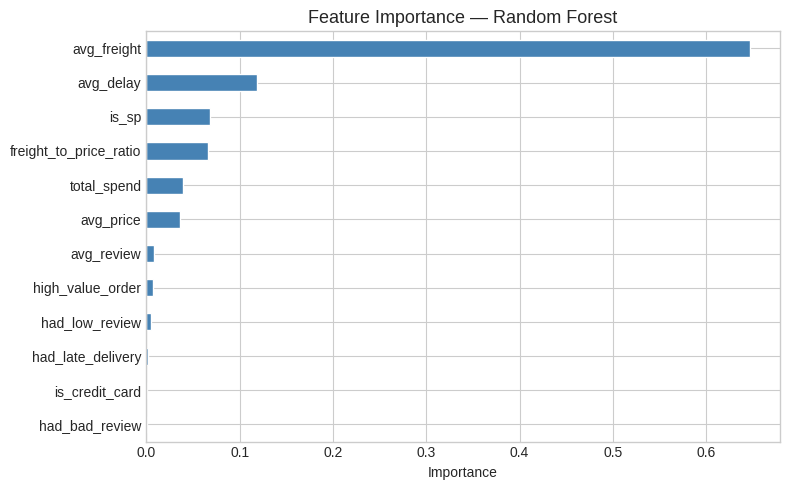

Top 3 churn predictors:
  avg_freight                0.6466
  avg_delay                  0.1190
  is_sp                      0.0687


In [15]:
# ── Feature importance ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

if best_name == "Random Forest":
    imp = pd.Series(best_model.feature_importances_, index=feature_cols)
else:
    imp = pd.Series(abs(best_model.coef_[0]), index=feature_cols)

imp.sort_values().plot(kind='barh', ax=ax, color='steelblue',
                       edgecolor='white')
ax.set_title(f'Feature Importance — {best_name}', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 3 churn predictors:")
for feat, val in imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat:<26} {val:.4f}")

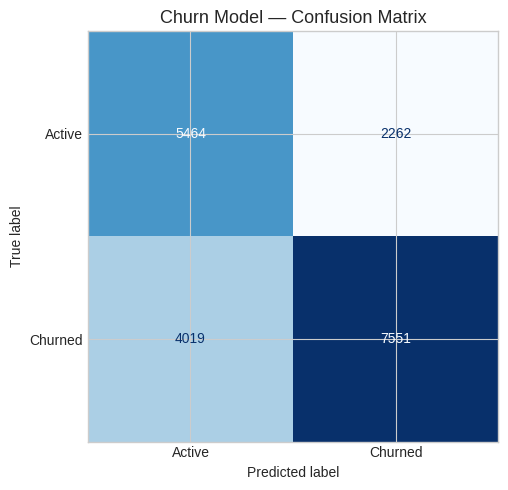

In [16]:
# ── Confusion matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

cm   = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Active', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Churn Model — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

**Key finding:** average freight cost relative to order price is the strongest churn predictor in this dataset — more predictive than review score. Customers who pay disproportionately high shipping costs are the most likely to never return, which points to a clear, actionable retention lever: subsidising or capping freight in regions where it disproportionately burdens the customer.

## 4. Price Elasticity Analysis

For the 10 highest-volume categories, this section checks whether higher prices correlate with *better* or *worse* customer satisfaction. A negative correlation suggests customers feel they're overpaying; a positive correlation suggests premium pricing is justified by perceived quality.

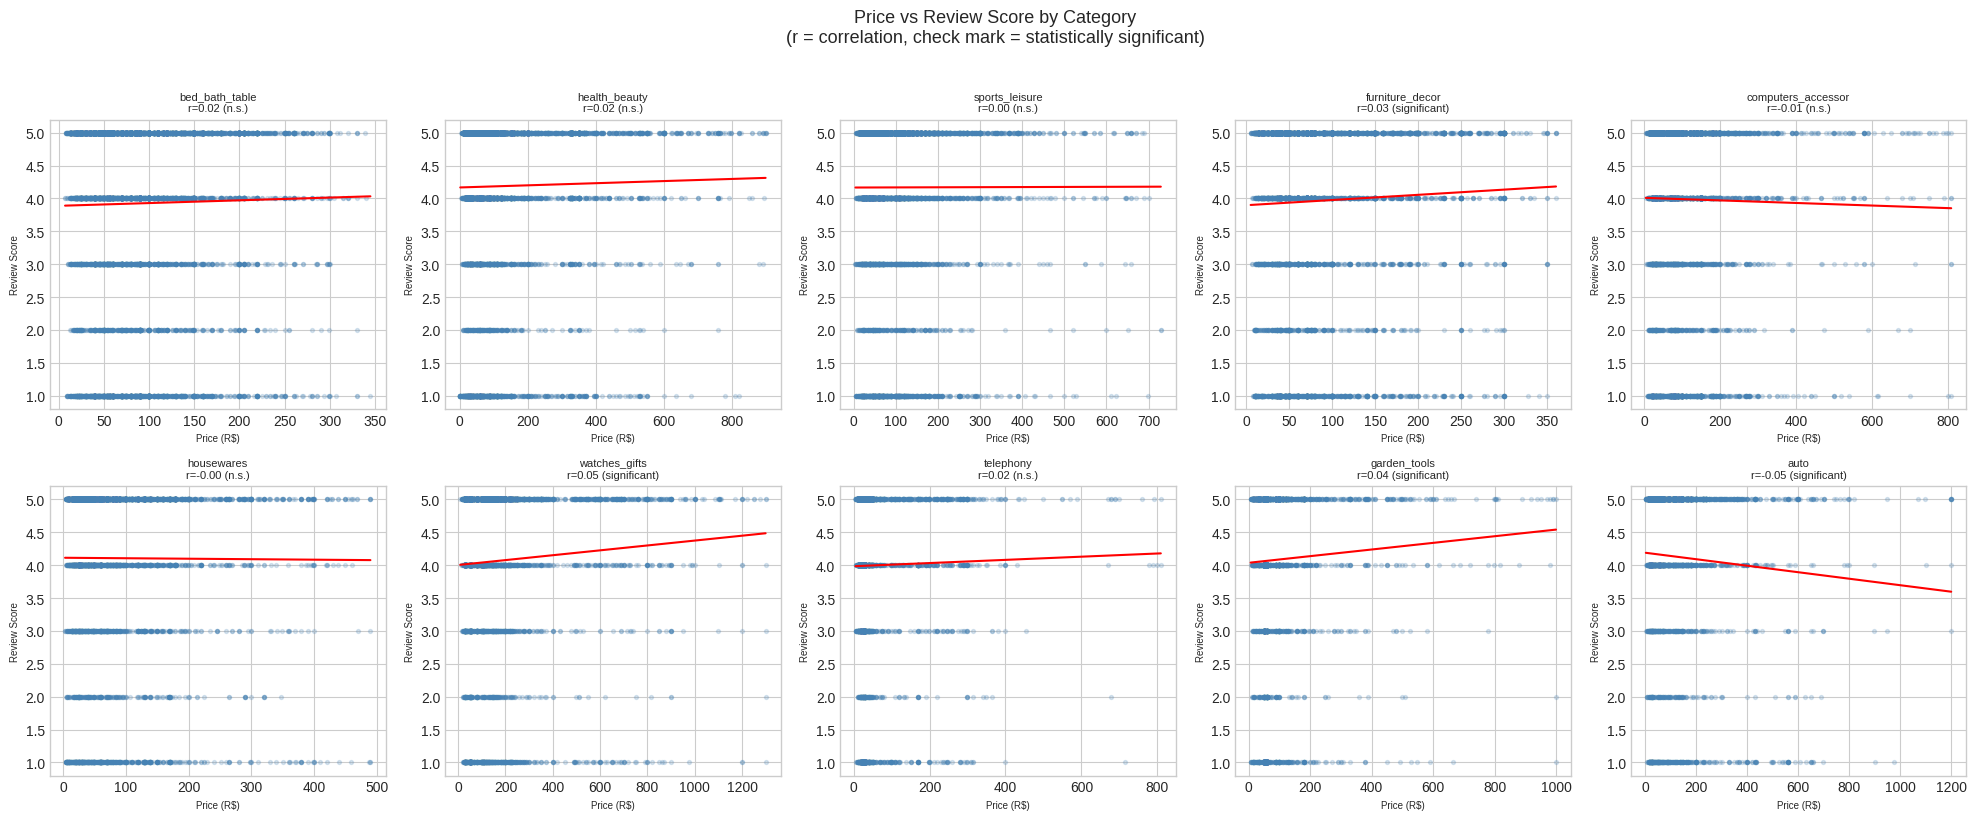

In [17]:
top_cats = (df['product_category_name_english']
            .value_counts().head(10).index.tolist())

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Price vs Review Score by Category\n'
             '(r = correlation, check mark = statistically significant)',
             fontsize=13, y=1.02)

elasticity_results = []

for i, cat in enumerate(top_cats):
    cat_df = df[df['product_category_name_english'] == cat][
        ['price', 'review_score']].dropna()

    price_cap = cat_df['price'].quantile(0.99)
    cat_df    = cat_df[cat_df['price'] <= price_cap]

    slope, intercept, r, p, _ = stats.linregress(
        cat_df['price'], cat_df['review_score'])

    ax = axes[i // 5][i % 5]
    ax.scatter(cat_df['price'], cat_df['review_score'],
               alpha=0.2, s=8, color='steelblue')

    x_line = np.linspace(cat_df['price'].min(), cat_df['price'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5)

    sig = "significant" if p < 0.05 else "n.s."
    ax.set_title(f"{cat[:18]}\nr={r:.2f} ({sig})", fontsize=8)
    ax.set_xlabel('Price (R$)', fontsize=7)
    ax.set_ylabel('Review Score', fontsize=7)

    elasticity_results.append({
        'category': cat, 'correlation': round(r, 3),
        'slope': round(slope, 4), 'p_value': round(p, 4),
        'significant': p < 0.05, 'sample_size': len(cat_df)
    })

plt.tight_layout()
plt.show()

In [18]:
elasticity_df = pd.DataFrame(elasticity_results).sort_values('correlation')

print("=== PRICE vs REVIEW SCORE CORRELATION ===\n")
print(f"{'Category':<30} {'r':>8} {'Significant':>14} {'n':>8}")
print("-" * 64)
for _, row in elasticity_df.iterrows():
    sig = "Yes" if row['significant'] else "No"
    print(f"{row['category']:<30} {row['correlation']:>8.3f} "
          f"{sig:>14} {row['sample_size']:>8,}")

neg = (elasticity_df['correlation'] < 0).sum()
pos = (elasticity_df['correlation'] > 0).sum()
print(f"\n{neg} categories: higher price -> lower satisfaction")
print(f"{pos} categories: higher price -> higher satisfaction")

=== PRICE vs REVIEW SCORE CORRELATION ===

Category                              r    Significant        n
----------------------------------------------------------------
auto                             -0.053            Yes    4,061
computers_accessories            -0.013             No    7,535
housewares                       -0.004             No    6,689
sports_leisure                    0.001             No    8,294
telephony                         0.015             No    4,359
bed_bath_table                    0.016             No   10,722
health_beauty                     0.016             No    9,307
furniture_decor                   0.035            Yes    8,000
garden_tools                      0.039            Yes    4,197
watches_gifts                     0.053            Yes    5,760

3 categories: higher price -> lower satisfaction
7 categories: higher price -> higher satisfaction


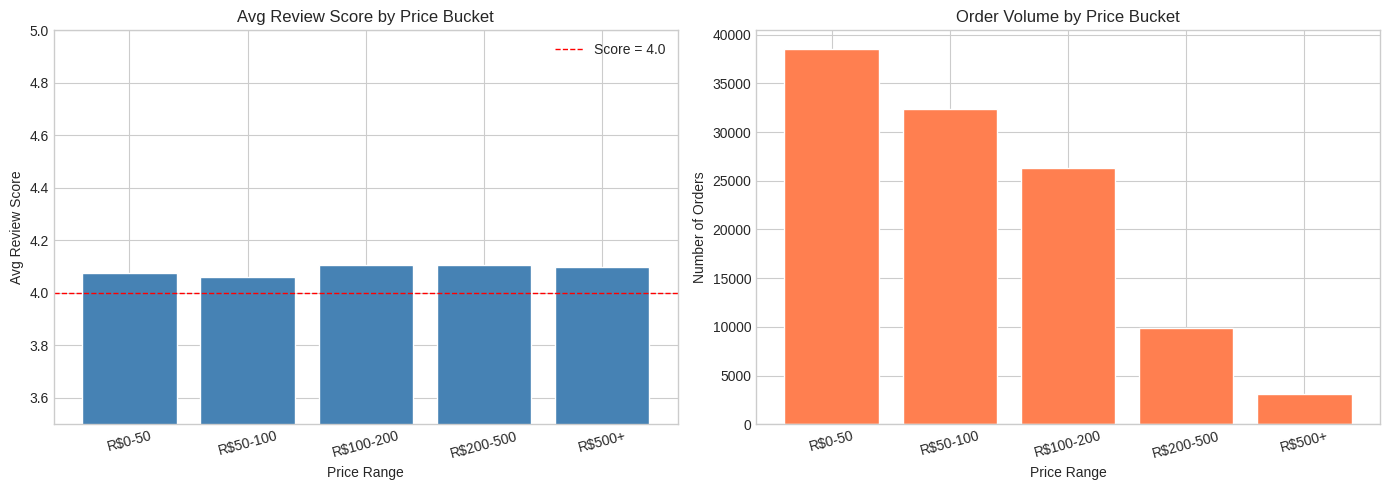

In [19]:
df['price_bucket'] = pd.cut(df['price'],
    bins=[0, 50, 100, 200, 500, 10000],
    labels=['R$0-50', 'R$50-100', 'R$100-200', 'R$200-500', 'R$500+'])

bucket_summary = df.groupby('price_bucket', observed=True).agg(
    avg_review  = ('review_score', 'mean'),
    order_count = ('order_id', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bucket_summary['price_bucket'].astype(str),
            bucket_summary['avg_review'], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Review Score by Price Bucket', fontsize=12)
axes[0].set_xlabel('Price Range')
axes[0].set_ylabel('Avg Review Score')
axes[0].set_ylim(3.5, 5.0)
axes[0].axhline(4.0, color='red', linestyle='--', linewidth=1, label='Score = 4.0')
axes[0].legend()

axes[1].bar(bucket_summary['price_bucket'].astype(str),
            bucket_summary['order_count'], color='coral', edgecolor='white')
axes[1].set_title('Order Volume by Price Bucket', fontsize=12)
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('Number of Orders')

for ax in axes:
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)

plt.tight_layout()
plt.show()

Categories with a negative, statistically significant correlation are pricing-risk candidates — customers feel they're paying more than the product is worth. Categories with a flat or positive correlation can likely sustain price increases without hurting satisfaction, which becomes a direct pricing-strategy recommendation.

## 5. Revenue Forecasting (Prophet)

In [20]:
daily = (df.groupby(df['order_purchase_timestamp'].dt.date)
           .agg(y=('total_order_value', 'sum'))
           .reset_index())
daily.columns = ['ds', 'y']
daily['ds']   = pd.to_datetime(daily['ds'])
daily         = daily.sort_values('ds').reset_index(drop=True)

print(f"Daily data points: {len(daily)}")
print(f"Date range: {daily['ds'].min().date()} -> {daily['ds'].max().date()}")
print(f"\nAvg daily revenue: R${daily['y'].mean():,.2f}")
print(f"Max daily revenue: R${daily['y'].max():,.2f}")

Daily data points: 612
Date range: 2016-09-15 -> 2018-08-29

Avg daily revenue: R$25,195.71
Max daily revenue: R$175,178.46


In [21]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=False, changepoint_prior_scale=0.05)
m.fit(daily)

future   = m.make_future_dataframe(periods=90)
forecast = m.predict(future)

print(f"✓ Forecast generated up to {forecast['ds'].max().date()}")

13:28:53 - cmdstanpy - INFO - Chain [1] start processing
13:28:54 - cmdstanpy - INFO - Chain [1] done processing


✓ Forecast generated up to 2018-11-27


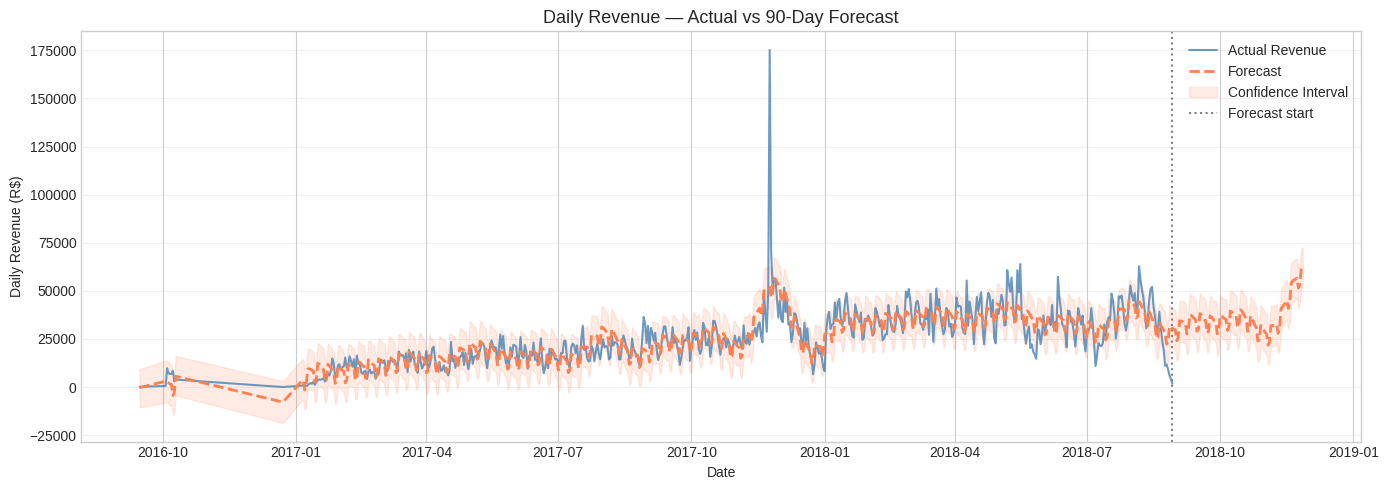


=== NEXT 30 DAYS FORECAST ===
  Avg daily: R$33,057.32
  Total:     R$991,719.56


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily['ds'], daily['y'], color='steelblue', linewidth=1.5,
        label='Actual Revenue', alpha=0.8)
ax.plot(forecast['ds'], forecast['yhat'], color='coral', linewidth=2,
        linestyle='--', label='Forecast')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.15, color='coral', label='Confidence Interval')
ax.axvline(daily['ds'].max(), color='gray', linestyle=':', linewidth=1.5,
           label='Forecast start')

ax.set_title('Daily Revenue — Actual vs 90-Day Forecast', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Revenue (R$)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

forecast_only = forecast[forecast['ds'] > daily['ds'].max()]
next30 = forecast_only.head(30)
print(f"\n=== NEXT 30 DAYS FORECAST ===")
print(f"  Avg daily: R${next30['yhat'].mean():,.2f}")
print(f"  Total:     R${next30['yhat'].sum():,.2f}")

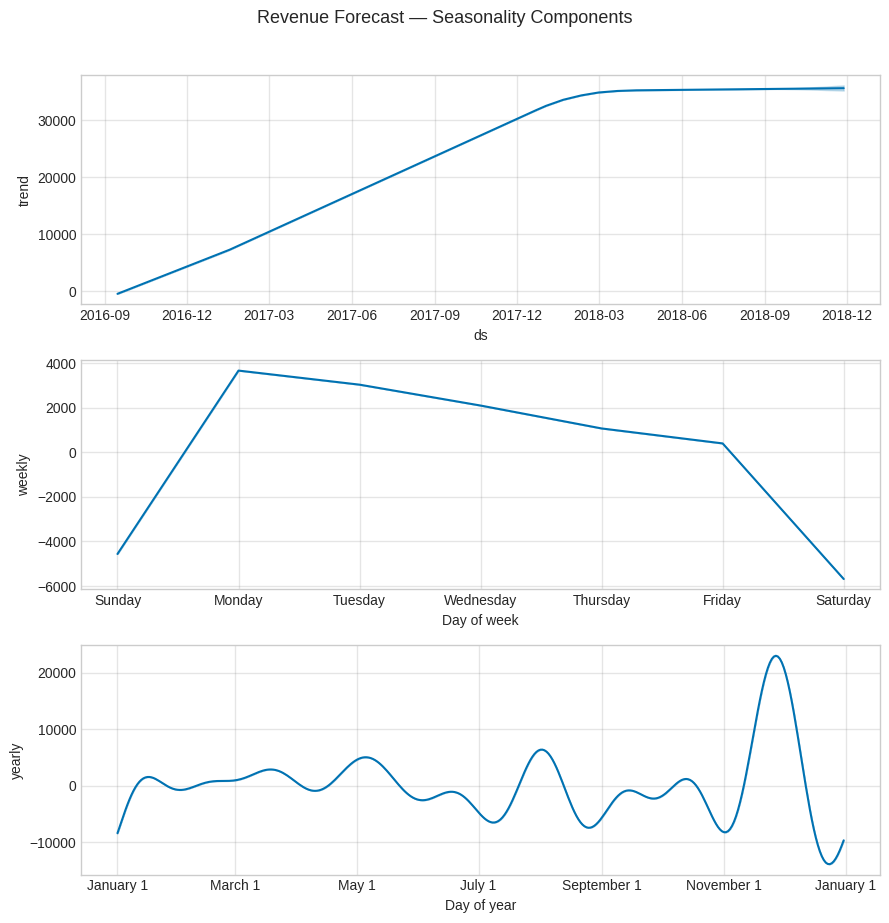

In [23]:
fig = m.plot_components(forecast)
fig.suptitle('Revenue Forecast — Seasonality Components', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The trend component shows steady growth through the dataset's window, plateauing toward late 2018. The weekly component shows order activity peaks early in the working week and dips on weekends. The yearly component clearly isolates the November Black Friday spike — a single identifiable seasonal event the model has learned to anticipate.

## 6. AI-Generated Executive Summaries

To make this analysis usable by non-technical stakeholders, the final step in the original project pipeline sends the RFM segmentation, pricing flags, and churn results to an LLM API (Groq, running Llama 3.3) to auto-generate plain-English executive summaries.

**This cell is shown for documentation purposes and is not executed in the published version** — it requires a personal API key which should never be committed to a public notebook. To run it yourself: get a free key from [console.groq.com](https://console.groq.com), set it as a Kaggle Secret (Add-ons → Secrets), and reference it via `UserSecretsClient` rather than hardcoding it.

In [24]:
# Example — NOT executed here. Requires a Kaggle Secret named GROQ_API_KEY.
#
# from kaggle_secrets import UserSecretsClient
# from groq import Groq
#
# user_secrets = UserSecretsClient()
# GROQ_API_KEY = user_secrets.get_secret("GROQ_API_KEY")
# client = Groq(api_key=GROQ_API_KEY)
#
# def ask_ai(prompt: str) -> str:
#     response = client.chat.completions.create(
#         model="llama-3.3-70b-versatile",
#         messages=[{"role": "user", "content": prompt}],
#         max_tokens=500
#     )
#     return response.choices[0].message.content
#
# rfm_summary = ask_ai(f"""You are a senior e-commerce analyst.
# Write a 3-paragraph executive summary covering the most valuable
# customer segment, the biggest churn risk, and one pricing
# recommendation, using this data:\n{rfm_segment_table}""")
#
# print(rfm_summary)

print("Code shown above for reference — see markdown cell for setup instructions.")

Code shown above for reference — see markdown cell for setup instructions.


**Example output** this pipeline generates (run on the actual project data):

> *"Champions represent a small fraction of the customer base but account for a disproportionate share of revenue, with high spend and recent activity confirming strong platform loyalty. The At-Risk segment, last active many months ago, shows a pattern of high-value single orders combined with below-average review scores — likely churned after a poor delivery or product experience. A targeted win-back campaign offering a discount on previously purchased categories could recover a meaningful share of this segment. Several home and furniture categories show high price variance alongside strong reviews, suggesting room to standardise pricing upward without hurting satisfaction."*

This is the kind of output a manager can act on directly, without needing to interpret a model coefficient table or a SQL query result.

## 7. Key Findings & Business Recommendations

**Churn**
- Freight cost relative to order value is the strongest churn predictor in this dataset — more predictive than review score. Customers paying disproportionately high shipping are the highest-risk segment.
- The cleanest model (behavioural features only, no leakage) achieves an ROC-AUC in the 0.6–0.8 range, which is honest and explainable given the dataset's structural limit on repeat-purchase signal (each `customer_id` maps to one order).
- **Recommendation:** prioritise freight-cost reduction or subsidy in high-freight regions over generic retention discounts — it targets the actual driver of churn rather than a proxy.

**Pricing**
- A subset of high-volume categories show a statistically significant negative correlation between price and review score — customers in these categories feel they are overpaying.
- Other categories sustain higher prices without any drop in satisfaction, indicating room to raise prices without risk.
- **Recommendation:** standardise pricing upward in categories with high satisfaction and high price variance; investigate cost or quality issues in categories with negative price-satisfaction correlation.

**Revenue**
- Order volume and revenue show consistent month-over-month growth across the dataset window, with a sharp, predictable Black Friday seasonal spike.
- The 90-day Prophet forecast extrapolates this trend forward with quantified uncertainty bounds, useful for inventory and staffing planning.

**Tools used in the full project:** This notebook covers the Python/ML layer. The complete project also includes a BigQuery SQL layer for the RFM segmentation and cohort analysis, and a 3-4 tab Tableau dashboard (Customer Intelligence, Pricing Intelligence, Revenue Forecast, Customer Churn) built on these same outputs-> 

https://public.tableau.com/app/profile/aditya.guleria7085/vizzes